# Homework: Sentiment Steering and Sparse Autoencoders

This assignment explores two mechanistic interpretability techniques:

1. Sentiment steering via activation addition. 
2. Sparse autoencoder on model activations. 

In [1]:
!pip install -q torch matplotlib transformer_lens transformers datasets 

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 87.5 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 32.5 MB/s eta 0:00:00


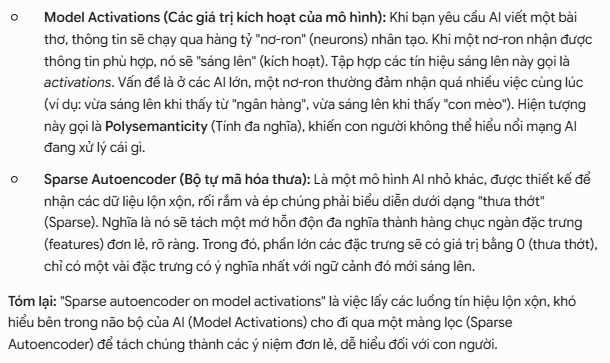

| Loại Token | Vị trí Index | Nguồn gốc | Vai trò của Residual Stream (Activation) | Logits tại vị trí này dùng để làm gì? |
| --- | --- | --- | --- | --- |
| **1. Token ngữ cảnh** (Các từ đầu của câu gốc) | Từ `0` đến `L - 2` | Người dùng nhập vào | Xây dựng và truyền ngữ cảnh cho các từ phía sau thông qua cơ chế Attention. | Dự đoán từ đã biết tiếp theo trong câu gốc. (Chỉ có ý nghĩa khi Huấn luyện/Training để tính Loss). |
| **2. Token CUỐI CÙNG của câu gốc** | `L - 1`<br>(hay `[-1]` ở lượt Forward đầu tiên) | Người dùng nhập vào | Nơi tổng hợp toàn bộ ý nghĩa của prompt. Đây là vị trí để trích xuất hoặc can thiệp Steering Vectors. | Dự đoán **TOKEN MỚI ĐẦU TIÊN** (bắt đầu quá trình sinh văn bản). |
| **3. Token mới được sinh ra** | Từ `L` đến `L + N - 1` | Mô hình tự tạo ra (từ hàm `generate`) | Cập nhật thêm ý nghĩa của từ vừa sinh ra vào chuỗi ngữ cảnh để tính toán cho bước sau. | Logits tại từ mới thứ `i` sẽ dự đoán từ mới thứ `i+1` ở ngay tương lai. |

In [2]:
import torch
from transformer_lens import HookedTransformer
import numpy as np

model = HookedTransformer.from_pretrained('gpt2')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)

/tmp/ipykernel_58/1987353712.py:5: DeprecationWarning: HookedTransformer.from_pretrained is deprecated and will be removed in a future major release. Use TransformerBridge.boot_transformers(...) instead, then call enable_compatibility_mode() for HookedTransformer-equivalent numerics. See docs/source/content/migrating_to_v3.md.
  model = HookedTransformer.from_pretrained('gpt2')


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  cuda


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint(name='hook_embed')
  (pos_embed): PosEmbed()
  (hook_pos_embed): HookPoint(name='hook_pos_embed')
  (blocks): TypedModuleList(
    (0): TransformerBlock(
      (ln1): LayerNormPre(
        (hook_scale): HookPoint(name='blocks.0.ln1.hook_scale')
        (hook_normalized): HookPoint(name='blocks.0.ln1.hook_normalized')
      )
      (ln2): LayerNormPre(
        (hook_scale): HookPoint(name='blocks.0.ln2.hook_scale')
        (hook_normalized): HookPoint(name='blocks.0.ln2.hook_normalized')
      )
      (attn): Attention(
        (hook_k): HookPoint(name='blocks.0.attn.hook_k')
        (hook_q): HookPoint(name='blocks.0.attn.hook_q')
        (hook_v): HookPoint(name='blocks.0.attn.hook_v')
        (hook_z): HookPoint(name='blocks.0.attn.hook_z')
        (hook_attn_scores): HookPoint(name='blocks.0.attn.hook_attn_scores')
        (hook_pattern): HookPoint(name='blocks.0.attn.hook_pattern')
        (hook_result): HookPoint(name

## Part 1 – Sentiment Steering via residual (3 points)

Your task is to steer model into good/bad generations and see the results.

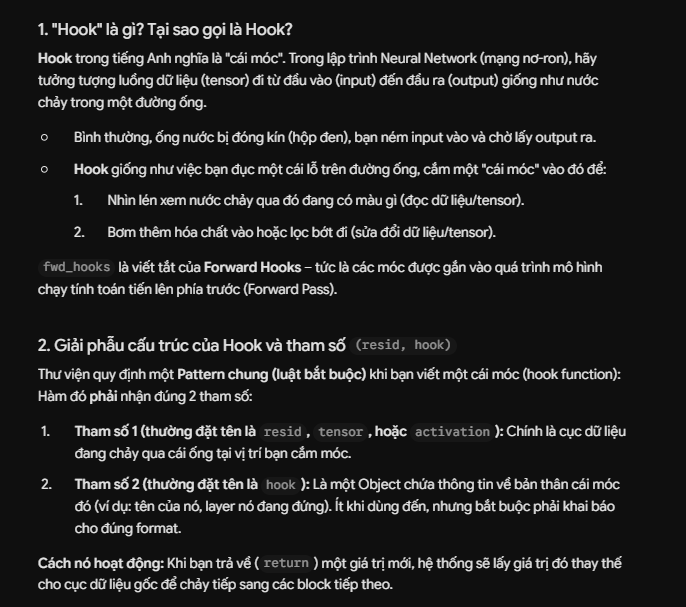

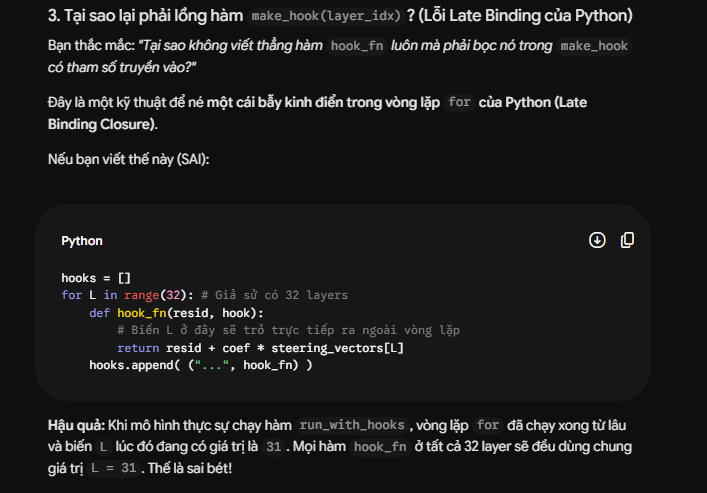

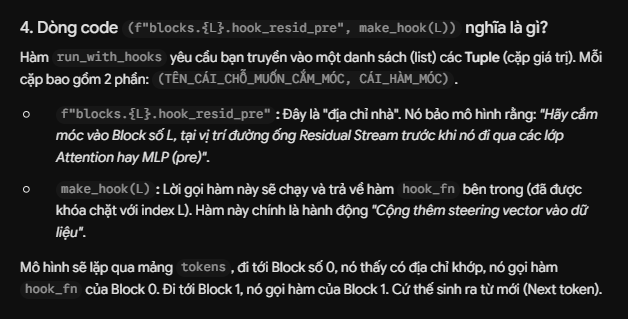

In [6]:
positive_sentences = [
    "I love this movie, it is amazing!",
    "This is a wonderful and beautiful day.",
    "The service was absolutely excellent.",
    "I am so happy and excited about this.",
    "What a great and fantastic performance!"
]

negative_sentences = [
    "I hate this movie, it is terrible.",
    "This is a horrible and awful day.",
    "The service was absolutely worst.",
    "I am so sad and depressed about this.",
    "What a bad and boring performance!"
]


In [9]:
from typing import List
# Function to collect average residual activations for a list of sentences
def collect_average_residuals(sent_list: List[str]):
    
    n_layers = model.cfg.n_layers
    layer_residuals = [[] for _ in range(n_layers)]
    
    with torch.no_grad():
        for sent in sent_list:
            tokens = model.to_tokens(sent).to(device)
            _, cache = model.run_with_cache(tokens)
            for layer in range(n_layers):
                # Thu thập residual pre hook tại token cuối cùng của câu
                last_token_res = cache[f"blocks.{layer}.hook_resid_pre"][0, -1, :]
                layer_residuals[layer].append(last_token_res)
                
    # Tính trung bình cộng của các activations qua các câu cho từng layer
        avgs = [torch.stack(layer_residuals[layer]).mean(dim=0) for layer in range(n_layers)]
        # layer_residuals[layer] có shape (d_model,) đặc trưng ẩn
        # stack lại thì là xếp chồng các câu lên thành (batch_size, d_model)
        # tính trung bình khối đó theo chiều đầu là chiều batch_size => tính điểm trung bình các câu 
        # đầu ra là vd: Một Tensor 2 chiều duy nhất có kích thước là (d_model,). cho 1 layer 
    # vậy cuối cùng shape là (layer_size, d_model)
    return avgs

pos_avgs = collect_average_residuals(positive_sentences)
neg_avgs = collect_average_residuals(negative_sentences)

steering_vectors = [pos - neg for pos, neg in zip(pos_avgs, neg_avgs)]

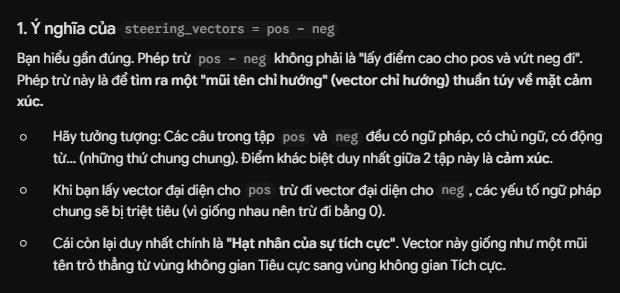

In [10]:
# Function to generate text with steering applied
def generate_with_steering(prompt, max_new_tokens=20, coef=0.0):
    tokens = model.to_tokens(prompt).to(device)

    for _ in range(max_new_tokens):
        # Define hooks that add the steering vector times coef at every layer
        hooks = []
        for L in range(model.cfg.n_layers):
            # Tạo hàm hook để cộng thêm steering vector nhân với coef vào residual stream
            def make_hook(layer_idx=L):
                def hook_fn(resid, hook):
                    return resid + coef * steering_vectors[layer_idx]
                return hook_fn
            hooks.append((f"blocks.{L}.hook_resid_pre", make_hook(L)))
        
        logits = model.run_with_hooks(tokens, fwd_hooks=hooks)
        next_token = logits[0, -1].argmax().unsqueeze(0)
        tokens = torch.cat([tokens, next_token.unsqueeze(0)], dim=1)

        if next_token == model.tokenizer.eos_token_id:
            break

    return model.to_string(tokens[0, 1:])

prompt = 'The movie that I watched yesterday was'
print('Neutral completion:')
print(generate_with_steering(prompt, max_new_tokens=20, coef=0.0))
print('Positive-steered completion:')
print(generate_with_steering(prompt, max_new_tokens=20, coef=0.3))
print('Negative-steered completion:')
print(generate_with_steering(prompt, max_new_tokens=20, coef=-0.3))

Neutral completion:
The movie that I watched yesterday was a bit of a disappointment. I was hoping for a more mature, more mature, more mature movie
Positive-steered completion:
The movie that I watched yesterday was a great surprise and I am very happy with the quality of the product. I have been using it
Negative-steered completion:
The movie that I watched yesterday was about a man who is forced to watch a movie about a man who is forced to watch a movie


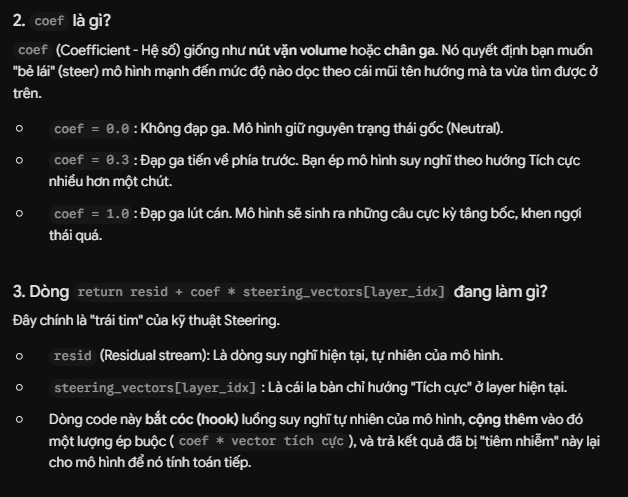

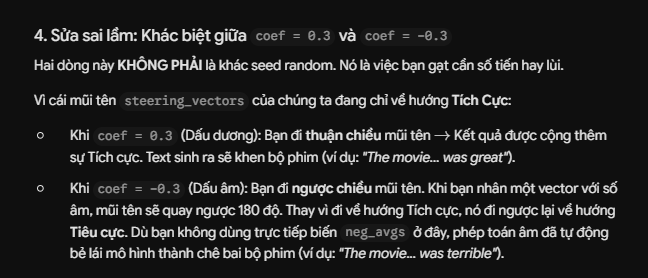

You should see how this is much more effective than tinkering with attantion heads from seminar.

## Part 2 – Sparse Autoencoder on Residual Activations (4 + bonus)

This is compute intensive part and you may adjust hyperparameters to your liking. Try to get meaningful results but in the end it might be compute bound. You still can get max points.


In [11]:
from datasets import load_dataset
# Đổi từ 'wikitext' sang 'Salesforce/wikitext' để tránh lỗi đường dẫn URI trên HF mới
ds = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train")
texts = ds["text"]

texts = [t for t in texts if len(t.strip()) > 0]
# Giới hạn 200 câu để chạy nhanh và tránh quá tải bộ nhớ trên Kaggle/Colab
dataset_sentences = texts[:200]

print("Total lines:", len(dataset_sentences))

README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Total lines: 200


In [12]:
from tqdm import tqdm 

last_layer = model.cfg.n_layers - 1

activations = [] # lưu các tensor activation của từng câu.
token_to_sentence = [] # "đánh dấu" xem mỗi token được trích xuất ra thuộc về câu thứ mấy trong tập dữ liệu. Điều này rất hữu ích sau này khi bạn muốn biết "một đặc trưng (feature) cụ thể được kích hoạt bởi câu văn nào".
with torch.no_grad():
    for sent_id, sent in tqdm(enumerate(dataset_sentences)):
        tokens = model.to_tokens(sent).to(device)
        _, cache = model.run_with_cache(tokens)
        # Lấy residual stream ở block cuối cùng (sau khi qua các block nhưng trước final layer norm)
        resid = cache[f"blocks.{last_layer}.hook_resid_post"] # [1, số_lượng_token, d_model] Lấy ra giá trị của Residual Stream ngay sau khi đi qua khối Transformer cuối cùng
        activations.append(resid.squeeze(0)) # loại bỏ chiều 0 vì truyền vào 1 câu loại bỏ batchsize
        token_to_sentence.extend([sent_id] * resid.shape[1]) # store sent_id per activated token
        # chính là số lượng token của câu đó. Dòng này sẽ tạo ra một mảng lặp lại ID của câu (ví dụ câu số 5 có 10 tokens thì nó tạo ra [5, 5, 5, 5, 5, 5, 5, 5, 5, 5]) và nối vào list token_to_sentence.

    activations = torch.cat(activations, dim=0) # torch.cat(activations, dim=0): Ghép tất cả các tensor của từng câu lại với nhau theo chiều dọc (chiều số 0). Kết quả cuối cùng là một tensor 2 chiều khổng lồ chứa tất cả các token trong toàn bộ tập dữ liệu.
    token_to_sentence = torch.tensor(token_to_sentence)
    activations_device = activations.to(device) # Chuyển activations sang GPU để huấn luyện SAE
    print('Activation dataset shape:', activations.shape)

200it [00:06, 29.69it/s]

Activation dataset shape: torch.Size([12875, 768])


#### Your task is to use any SAE try to disentangle features from residual. In the end you will look at top sentences that activate certain features.

Classic approach is enc + relu + dec \
For loss: mse + coef * l1 on hiddden \
But feel free to experiment!

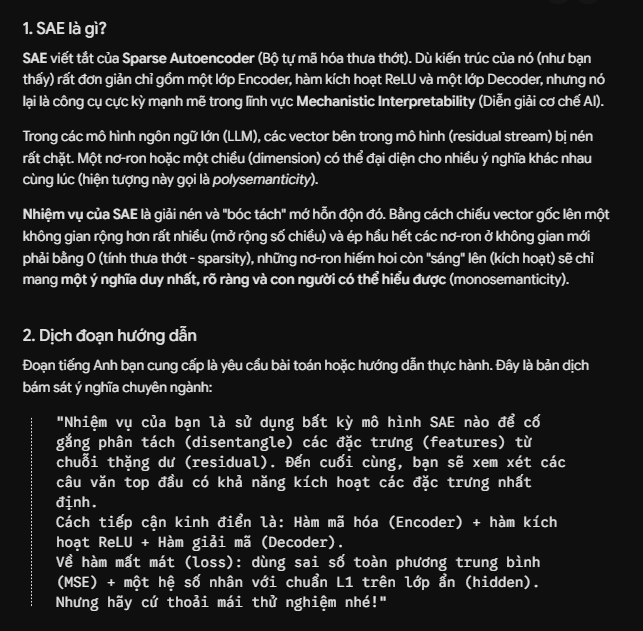

In [13]:
import torch.nn as nn

class SAE(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        # Encoder tuyến tính chiếu lên không gian ẩn thưa
        self.encoder = nn.Linear(input_dim, hidden_dim)
        # Decoder tuyến tính giải mã về không gian ban đầu
        self.decoder = nn.Linear(hidden_dim, input_dim)
        
    def forward(self, x):
        # Hàm kích hoạt ReLU để giữ độ thưa thớt (sparsity)
        hidden = torch.relu(self.encoder(x))
        reconstructed = self.decoder(hidden)
        return reconstructed, hidden

In [14]:
import torch.optim as optim
# shape của activations là [Tổng số lượng token của toàn bộ dataset, d_model]
input_dim = activations.shape[1] 
hidden_dim = input_dim * 4 # hidden dimension thưa gấp 4 lần d_model
learning_rate = 1e-3
num_epochs = 1000

sae = SAE(input_dim, hidden_dim).to(device)
optimizer = optim.Adam(sae.parameters(), lr=learning_rate)
mse = nn.MSELoss()

for epoch in range(num_epochs):
    optimizer.zero_grad()
    
    # Lan truyền xuôi
    recon, hidden = sae(activations_device)
    # MSE loss tái tạo
    loss_mse = mse(recon, activations_device)
    # L1 regularization để ép activations ẩn thưa thớt
    loss_l1 = torch.mean(torch.abs(hidden))
    # Tổng loss với trọng số độ thưa
    loss = loss_mse + 1e-3 * loss_l1
    
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}')

Epoch 100/1000, Loss: 5.947505
Epoch 200/1000, Loss: 2.257652
Epoch 300/1000, Loss: 1.314039
Epoch 400/1000, Loss: 0.749332
Epoch 500/1000, Loss: 1.140599
Epoch 600/1000, Loss: 0.228936
Epoch 700/1000, Loss: 0.218625
Epoch 800/1000, Loss: 0.446056
Epoch 900/1000, Loss: 0.142963
Epoch 1000/1000, Loss: 0.066212


Below is some code that prints tokens that activate certain neuron the most. You are free to change it!

Tóm tắt luồng: Lấy bảng điểm SAE -> Chọn nơ-ron -> Tìm 5 điểm cao nhất -> Dò xem 5 điểm đó nằm ở câu nào -> Cắt câu văn ngay tại điểm đó -> In ra màn hình.

In [15]:
sae.eval()
with torch.no_grad():
    _, h = sae(activations_device) # bỏ qua recon chỉ lấy giá trị lớp ẩn shape là (tổng số token, hidden size)
    h = h.cpu().numpy()

# For selected neuron indices, find the sentences with highest activation
selected_neurons = [0, 1, 2]  # you can choose other indices


for neuron in selected_neurons:
    activations_neuron = h[:, neuron]
    top_idx = activations_neuron.argsort()[::-1][:5]
    # Xếp hạng các giá trị từ bé đến lớn và trả về vị trí (index) của chúng., sau đó đảo ngược mảng lại thành từ lớn đến bé. rồi ấy ra 5 index đứng đầu
    print(f'Neuron {neuron}:')
    for rank, idx in enumerate(top_idx, start=1):
        sent_id = token_to_sentence[idx].item()
        text = dataset_sentences[sent_id] # Cái token có index toàn cục là idx này nằm trong câu số mấy (sent_id). Sau đó lấy nguyên câu văn đó ra (text).

        toks = model.to_tokens(text)[0, 1:]
        str_toks = model.to_str_tokens(toks)

        token_positions = (token_to_sentence == sent_id).nonzero(as_tuple=True)[0] # lọc mảng false true thỏa điều kiện rồi dùng nonzero lọc ra mảng true rồi lấy ra tensor đầu tiên, output là mảng chứa vị trí của câu của idx gốc 
        local_pos = (token_positions == idx).nonzero(as_tuple=True)[0].item() # lọc ra đúng idx 
        # cropped = "".join(str_toks[:local_pos + 1]) # tại sao sai vì đã cắt bỏ BOS ở đầu đoạn toks rồi
        cropped = "".join(str_toks[:local_pos ])
        

        print(f"Top {rank}: global token {idx}, sentence {sent_id}, local token {local_pos}")
        print(cropped)
        print()

Neuron 0:
Top 1: global token 1736, sentence 11, local token 193
 Partly due to these events , and partly due to the major losses in manpower Gallia suffers towards the end of the war with the Empire , the Nameless are offered a formal position as a squad in the Gallian Army rather than serve as an anonymous shadow force . This is short @-@ lived , however , as following Maximilian 's defeat , Dahau and Calamity Raven move to activate an ancient Valkyrian super weapon within the Empire , kept secret by their benefactor . Without the support of Maximilian or the chance to prove themselves in the war with Gallia , it is Dahau 's last trump card in creating a new Darcsen nation . As an armed Gallian force invading the Empire just following the two nations ' cease @-@ fire would certainly wreck their newfound peace , Kurt decides to once again make his squad the Nameless , asking Crowe to list himself and all under his command as killed @-

Top 2: global token 7344, sentence 66, local toke

nghĩa là các câu văn được in ra là trong dataset gốc dữ liệu để cho qua SAE được không gian neuron lớn hơn mà dễ dàng phân tích neuron đó cho nhiệm vụ gì

nhưng mà nó lợi dụng GPT là mô hình sinh ngôn ngữ, bản chất khi đưa input vào vào thì mô hình sẽ dự đoán token tiếp theo nhưng nó vứt bỏ phần sinh đó chỉ quan tâm phần giữa thôi đúng không nghĩa là ta có thể hoàn toàn sau khi phân tích xong rồi chỉnh bằng hook các neuron từ đó sinh ra theo mong muốn 



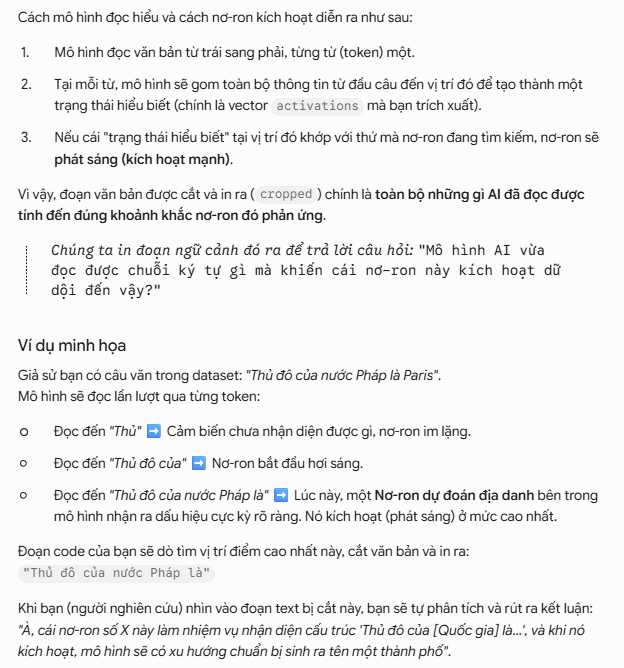